In [ ]:
"""
Breast Ultrasound Images (BUSI) Dataset
Classes: Benign, Malignant, Normal
Total images: ~780 (437 benign, 210 malignant, 133 normal)
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, EfficientNetB0, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

# ==================== PART 1: DATASET LOADER ====================

class BUSIDataset:
    """
    Load and prepare Breast Ultrasound Images (BUSI) dataset
    """
    
    def __init__(self, dataset_path, img_size=(224, 224)):
        """
        Args:
            dataset_path: path to Dataset_BUSI_with_GT folder
            img_size: target image size
        """
        self.dataset_path = dataset_path
        self.img_size = img_size
        self.class_names = ['benign', 'malignant', 'normal']
        self.class_labels = {'benign': 0, 'malignant': 1, 'normal': 2}
        
    def load_data(self):
        """
        Load all images and labels from the dataset
        """
        print("\n" + "="*60)
        print("📊 LOADING BUSI DATASET")
        print("="*60)
        
        images = []
        labels = []
        paths = []
        
        # Load each class
        for class_name in self.class_names:
            class_folder = os.path.join(self.dataset_path, class_name)
            
            if not os.path.exists(class_folder):
                print(f"❌ Folder not found: {class_folder}")
                continue
            
            # Get all image files (excluding mask files if any)
            image_files = glob(os.path.join(class_folder, "*.png"))
            image_files += glob(os.path.join(class_folder, "*.jpg"))
            image_files += glob(os.path.join(class_folder, "*.jpeg"))
            
            # Filter out mask files if they have "_mask" in name
            image_files = [f for f in image_files if '_mask' not in f.lower()]
            
            print(f"\n📁 Class: {class_name}")
            print(f"   Found {len(image_files)} images")
            
            for img_path in image_files:
                try:
                    # Read image
                    img = cv2.imread(img_path)
                    
                    if img is None:
                        print(f"   ⚠️ Could not read: {os.path.basename(img_path)}")
                        continue
                    
                    # Convert BGR to RGB
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    
                    # Resize
                    img_resized = cv2.resize(img_rgb, self.img_size)
                    
                    # Normalize to [0,1]
                    img_normalized = img_resized.astype('float32') / 255.0
                    
                    images.append(img_normalized)
                    labels.append(self.class_labels[class_name])
                    paths.append(img_path)
                    
                except Exception as e:
                    print(f"   ❌ Error loading {img_path}: {e}")
        
        # Convert to numpy arrays
        images = np.array(images)
        labels = np.array(labels)
        
        print(f"\n✅ Total images loaded: {len(images)}")
        print(f"✅ Image shape: {images[0].shape}")
        print(f"✅ Labels shape: {labels.shape}")
        
        # Print class distribution
        print("\n📈 Class distribution:")
        for class_name in self.class_names:
            count = np.sum(labels == self.class_labels[class_name])
            percentage = (count / len(labels)) * 100
            print(f"   {class_name}: {count} images ({percentage:.1f}%)")
        
        return images, labels, paths
    
    def create_data_generators(self, images, labels, batch_size=32, validation_split=0.2):
        """
        Create train/validation data generators with augmentation
        """
        print("\n" + "="*60)
        print("🔄 CREATING DATA GENERATORS")
        print("="*60)
        
        # Split data
        X_train, X_val, y_train, y_val = train_test_split(
            images, labels, 
            test_size=validation_split, 
            random_state=42, 
            stratify=labels
        )
        
        print(f"\n📊 Split summary:")
        print(f"   Training: {len(X_train)} images")
        print(f"   Validation: {len(X_val)} images")
        
        # Data augmentation for training
        train_datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True,
            fill_mode='nearest'
        )
        
        # Only normalization for validation
        val_datagen = ImageDataGenerator()
        
        # Create generators
        train_generator = train_datagen.flow(
            X_train, to_categorical(y_train, num_classes=3),
            batch_size=batch_size,
            shuffle=True,
            seed=42
        )
        
        val_generator = val_datagen.flow(
            X_val, to_categorical(y_val, num_classes=3),
            batch_size=batch_size,
            shuffle=False,
            seed=42
        )
        
        print(f"\n✅ Generators created successfully")
        
        return train_generator, val_generator, (X_val, y_val)


In [ ]:

# ==================== PART 2: MODEL BUILDING ====================

def build_model(input_shape=(224, 224, 3), num_classes=3, model_type='resnet50'):
    """
    Build transfer learning model for breast ultrasound classification
    
    Args:
        input_shape: input image shape
        num_classes: number of classes (3 for benign, malignant, normal)
        model_type: 'resnet50', 'efficientnet', or 'densenet'
    """
    print("\n" + "="*60)
    print(f"🏗️ BUILDING {model_type.upper()} MODEL")
    print("="*60)
    
    # Load pre-trained base model
    if model_type == 'resnet50':
        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
    elif model_type == 'efficientnet':
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
    elif model_type == 'densenet':
        base_model = DenseNet121(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    # Freeze base model initially
    base_model.trainable = False
    
    # Add custom classification head
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    
    print(f"\n📋 Model summary:")
    print(f"   Base model: {model_type} (frozen)")
    print(f"   Input shape: {input_shape}")
    print(f"   Output classes: {num_classes} (benign, malignant, normal)")
    print(f"   Total parameters: {model.count_params():,}")
    
    return model, base_model



In [ ]:
# ==================== PART 3: TRAINING ====================

def train_model(model, train_generator, val_generator, epochs=30):
    """
    Train the model with callbacks
    """
    print("\n" + "="*60)
    print("🎯 TRAINING MODEL")
    print("="*60)
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy', 
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')]
    )
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            'best_breast_ultrasound_model.h5',
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    # Train
    history = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        validation_data=val_generator,
        validation_steps=len(val_generator),
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    print("\n✅ Training complete!")
    return history

def fine_tune_model(model, base_model, train_generator, val_generator, epochs=15):
    """
    Fine-tune the pre-trained layers
    """
    print("\n" + "="*60)
    print("🔧 FINE-TUNING MODEL")
    print("="*60)
    
    # Unfreeze base model
    base_model.trainable = True
    
    # Freeze early layers, train later layers
    # For ResNet50, freeze first 100 layers
    if hasattr(base_model, 'layers'):
        for layer in base_model.layers[:100]:
            layer.trainable = False
    
    # Recompile with lower learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')]
    )
    
    # Continue training
    history = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        validation_data=val_generator,
        validation_steps=len(val_generator),
        epochs=epochs,
        verbose=1
    )
    
    return history


In [ ]:



# ==================== PART 4: EVALUATION ====================

def evaluate_model(model, X_val, y_val, class_names):
    """
    Comprehensive model evaluation
    """
    print("\n" + "="*60)
    print("📊 MODEL EVALUATION")
    print("="*60)
    
    # Get predictions
    y_pred_prob = model.predict(X_val, verbose=1)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    # Calculate metrics for each class
    accuracy = accuracy_score(y_val, y_pred)
    
    print(f"\n🎯 Overall Accuracy: {accuracy:.4f}")
    
    # Per-class metrics
    print("\n📋 Per-Class Performance:")
    for i, class_name in enumerate(class_names):
        # Binary metrics for this class
        y_true_binary = (y_val == i).astype(int)
        y_pred_binary = (y_pred == i).astype(int)
        
        sensitivity = recall_score(y_true_binary, y_pred_binary, zero_division=0)
        specificity = recall_score(y_true_binary, y_pred_binary, pos_label=0, zero_division=0)
        precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
        f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
        
        print(f"\n   {class_name.upper()}:")
        print(f"     Sensitivity (Recall): {sensitivity:.4f}")
        print(f"     Specificity: {specificity:.4f}")
        print(f"     Precision: {precision:.4f}")
        print(f"     F1-Score: {f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_val, y_pred, target_names=class_names))
    
    return {
        'accuracy': accuracy,
        'predictions': y_pred,
        'probabilities': y_pred_prob,
        'confusion_matrix': cm
    }


In [ ]:

# ==================== PART 5: VISUALIZATION ====================

def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training')
    axes[0, 0].plot(history.history['val_loss'], label='Validation')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Training')
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # AUC
    axes[0, 2].plot(history.history['auc'], label='Training')
    axes[0, 2].plot(history.history['val_auc'], label='Validation')
    axes[0, 2].set_title('AUC-ROC')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('AUC')
    axes[0, 2].legend()
    axes[0, 2].grid(True)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training')
    axes[1, 0].plot(history.history['val_precision'], label='Validation')
    axes[1, 0].set_title('Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training')
    axes[1, 1].plot(history.history['val_recall'], label='Validation')
    axes[1, 1].set_title('Recall (Sensitivity)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Learning rate
    if 'lr' in history.history:
        axes[1, 2].plot(history.history['lr'])
        axes[1, 2].set_title('Learning Rate')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('LR')
        axes[1, 2].set_yscale('log')
        axes[1, 2].grid(True)
    else:
        axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, class_names):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def visualize_predictions(model, X_val, y_val, class_names, num_samples=8):
    """Visualize sample predictions"""
    # Get predictions
    y_pred_prob = model.predict(X_val[:num_samples], verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    # Plot
    cols = 4
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
    axes = axes.flatten()
    
    for i in range(num_samples):
        axes[i].imshow(X_val[i])
        
        true_label = class_names[y_val[i]]
        pred_label = class_names[y_pred[i]]
        confidence = np.max(y_pred_prob[i])
        
        color = 'green' if y_val[i] == y_pred[i] else 'red'
        
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}", 
                         color=color)
        axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


In [ ]:
# ==================== PART 6: MAIN PIPELINE ====================

def main():
    """
    Main execution pipeline for BUSI dataset
    """
    print("="*60)
    print("🩺 BREAST ULTRASOUND IMAGE CLASSIFICATION")
    print("="*60)
    print("Classes: Benign, Malignant, Normal")
    
    # Set dataset path
    dataset_path = r"D:\TRIM3\Computer_Vision\Dataset_BUSI_with_GT"
    
    # Verify path exists
    if not os.path.exists(dataset_path):
        print(f"\n❌ Dataset path not found: {dataset_path}")
        print("Please update the path to your dataset location.")
        return
    
    # Step 1: Load dataset
    print("\n[1] Loading BUSI dataset...")
    busi = BUSIDataset(dataset_path, img_size=(224, 224))
    images, labels, paths = busi.load_data()
    
    if len(images) == 0:
        print("❌ No images loaded. Check dataset path.")
        return
    
    # Step 2: Create data generators
    print("\n[2] Creating data generators...")
    train_generator, val_generator, (X_val, y_val) = busi.create_data_generators(
        images, labels, batch_size=16, validation_split=0.2
    )
    
    # Step 3: Build model
    print("\n[3] Building ResNet50 model...")
    model, base_model = build_model(model_type='resnet50')
    
    # Step 4: Train initial model
    print("\n[4] Training initial model...")
    history1 = train_model(model, train_generator, val_generator, epochs=20)
    
    # Step 5: Fine-tune
    print("\n[5] Fine-tuning model...")
    history2 = fine_tune_model(model, base_model, train_generator, val_generator, epochs=10)
    
    # Combine histories
    history = type('obj', (object,), {
        'history': {
            'loss': history1.history['loss'] + history2.history['loss'],
            'val_loss': history1.history['val_loss'] + history2.history['val_loss'],
            'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
            'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
            'auc': history1.history['auc'] + history2.history['auc'],
            'val_auc': history1.history['val_auc'] + history2.history['val_auc'],
            'precision': history1.history['precision'] + history2.history['precision'],
            'val_precision': history1.history['val_precision'] + history2.history['val_precision'],
            'recall': history1.history['recall'] + history2.history['recall'],
            'val_recall': history1.history['val_recall'] + history2.history['val_recall']
        }
    })
    
    # Step 6: Evaluate
    print("\n[6] Evaluating model...")
    results = evaluate_model(model, X_val, y_val, busi.class_names)
    
    # Step 7: Visualizations
    print("\n[7] Visualizing results...")
    plot_training_history(history)
    plot_confusion_matrix(results['confusion_matrix'], busi.class_names)
    visualize_predictions(model, X_val, y_val, busi.class_names)
    
    # Step 8: Final report
    print("\n" + "="*60)
    print("📋 FINAL REPORT")
    print("="*60)
    print(f"""
🎯 Model Performance Summary:
----------------------------
Overall Accuracy: {results['accuracy']:.4f}

📊 Clinical Interpretation:
--------------------------
For breast cancer screening:
- High Sensitivity (Recall) is critical to catch malignancies
- High Specificity reduces unnecessary biopsies
- AUC-ROC shows overall diagnostic ability

✅ Model saved as: 'best_breast_ultrasound_model.h5'
    """)
    
    return model, results, busi


🩺 BREAST ULTRASOUND IMAGE CLASSIFICATION
Classes: Benign, Malignant, Normal

[1] Loading BUSI dataset...

📊 LOADING BUSI DATASET

📁 Class: benign
   Found 437 images

📁 Class: malignant
   Found 210 images

📁 Class: normal
   Found 133 images

✅ Total images loaded: 780
✅ Image shape: (224, 224, 3)
✅ Labels shape: (780,)

📈 Class distribution:
   benign: 437 images (56.0%)
   malignant: 210 images (26.9%)
   normal: 133 images (17.1%)

[2] Creating data generators...

🔄 CREATING DATA GENERATORS

📊 Split summary:
   Training: 624 images
   Validation: 156 images

✅ Generators created successfully

[3] Building ResNet50 model...

🏗️ BUILDING RESNET50 MODEL

📋 Model summary:
   Base model: resnet50 (frozen)
   Input shape: (224, 224, 3)
   Output classes: 3 (benign, malignant, normal)
   Total parameters: 24,768,899

[4] Training initial model...

🎯 TRAINING MODEL
Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.4518 - auc: 0.6365 - loss: 1.3596 - precision: 0.4711 - reca


Epoch 1: finished saving model to best_breast_ultrasound_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.4567 - auc: 0.6296 - loss: 1.2523 - precision: 0.4627 - recall: 0.3574 - val_accuracy: 0.5577 - val_auc: 0.6825 - val_loss: 1.0666 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.5455 - auc: 0.6781 - loss: 1.0438 - precision: 0.5579 - recall: 0.3974 
Epoch 2: val_accuracy did not improve from 0.55769
39/39 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5208 - auc: 0.6657 - loss: 1.0598 - precision: 0.5450 - recall: 0.3878 - val_accuracy: 0.5577 - val_auc: 0.7400 - val_loss: 0.9939 - val_precision: 0.8000 - val_recall: 0.0256 - learning_rate: 0.0010
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.4850 - auc: 0.6286 - loss: 1.0834 - precision: 0.5004 - recall: 0.3140 
Epoch 3: val_accuracy did not improve from 0.55769
39/39 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - 

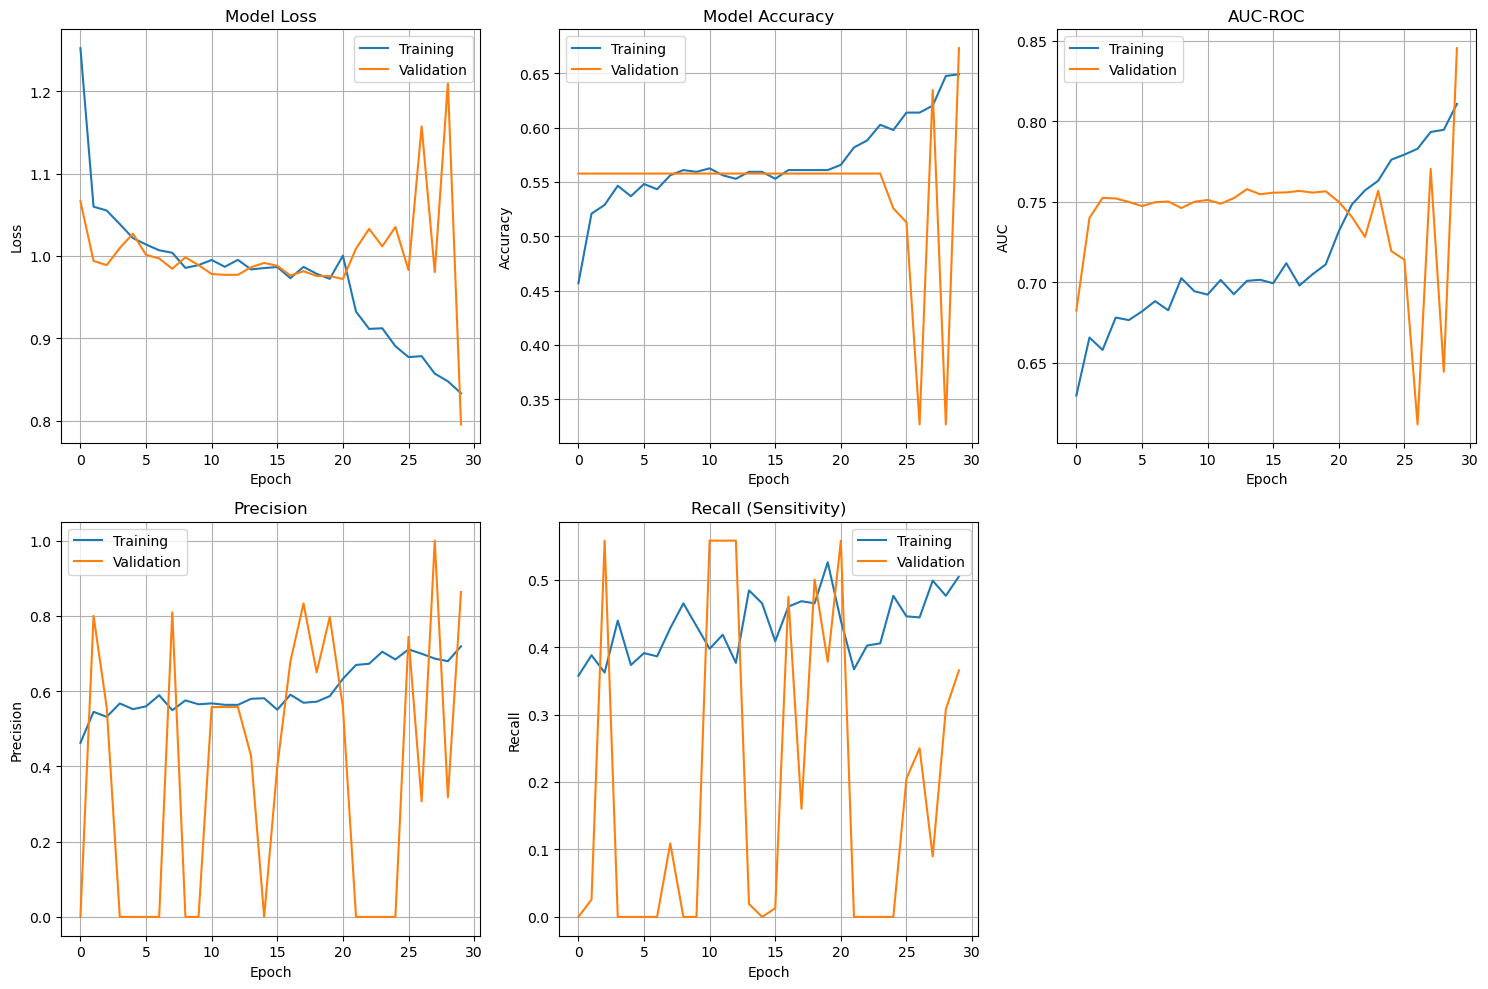

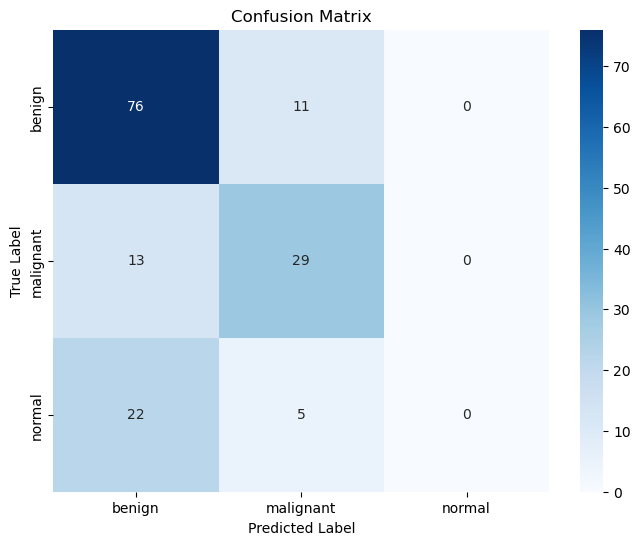

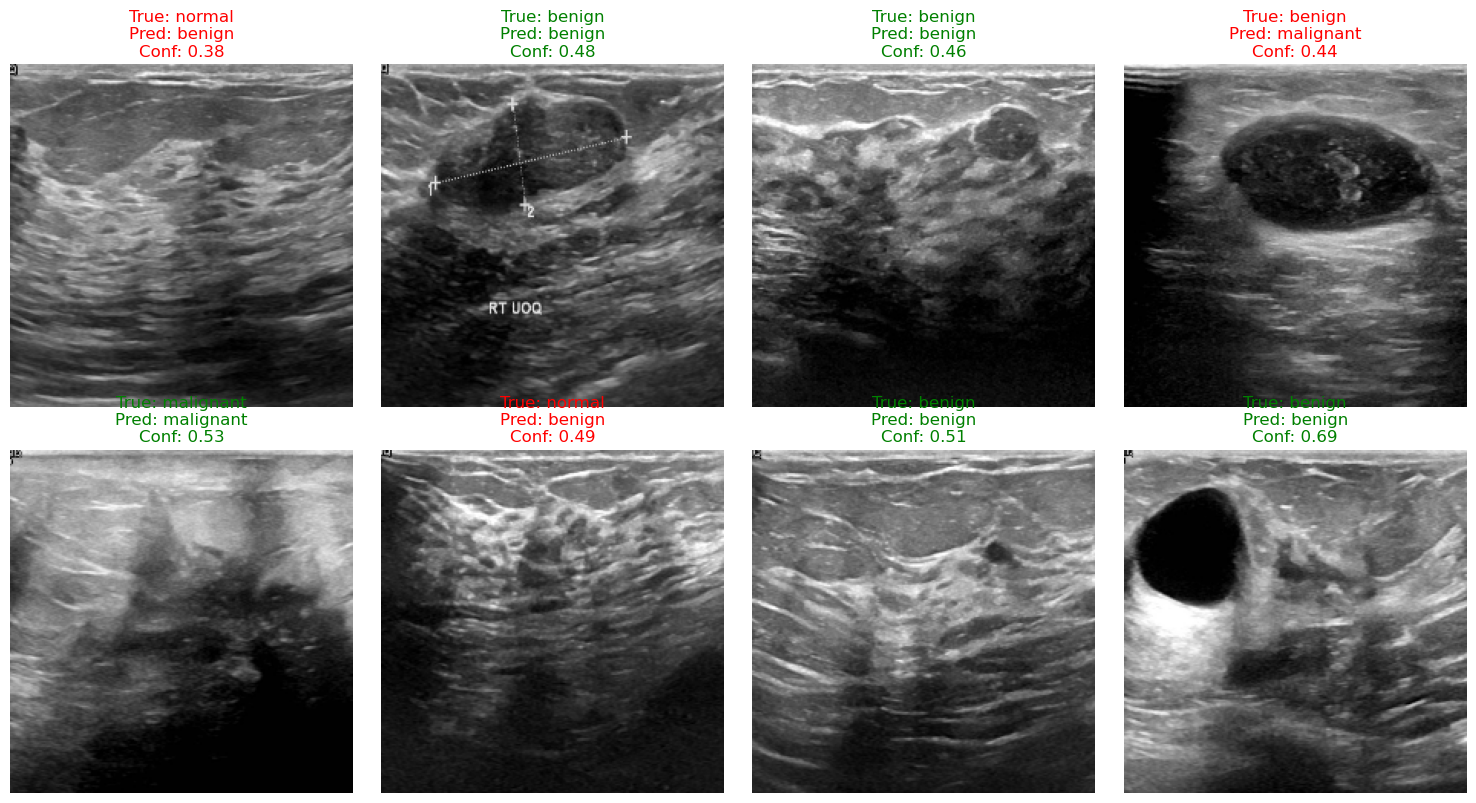


📋 FINAL REPORT

🎯 Model Performance Summary:
----------------------------
Overall Accuracy: 0.6731

📊 Clinical Interpretation:
--------------------------
For breast cancer screening:
- High Sensitivity (Recall) is critical to catch malignancies
- High Specificity reduces unnecessary biopsies
- AUC-ROC shows overall diagnostic ability

✅ Model saved as: 'best_breast_ultrasound_model.h5'
    

🔍 TEST ON SINGLE IMAGE


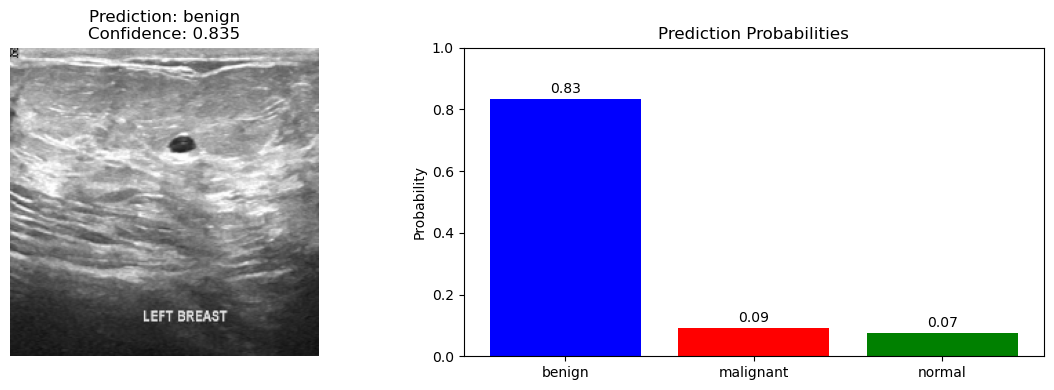

In [2]:


# ==================== PART 7: PREDICT SINGLE IMAGE ====================

def predict_single_image(model, image_path, class_names, img_size=(224, 224)):
    """
    Predict on a single ultrasound image
    """
    # Load and preprocess image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)
    
    # Predict
    probs = model.predict(img, verbose=0)[0]
    pred_class = np.argmax(probs)
    confidence = probs[pred_class]
    
    # Display
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img[0])
    plt.title(f"Prediction: {class_names[pred_class]}\nConfidence: {confidence:.3f}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    colors = ['blue', 'red', 'green']
    plt.bar(class_names, probs, color=colors)
    plt.ylabel('Probability')
    plt.title('Prediction Probabilities')
    plt.ylim(0, 1)
    
    # Add value labels
    for i, prob in enumerate(probs):
        plt.text(i, prob + 0.02, f'{prob:.2f}', ha='center')
    
    plt.tight_layout()
    plt.show()
    
    return class_names[pred_class], confidence

# ==================== RUN THE CODE ====================

if __name__ == "__main__":
    # Run main pipeline
    model, results, busi = main()
    
    # Optional: Test on a specific image
    print("\n" + "="*60)
    print("🔍 TEST ON SINGLE IMAGE")
    print("="*60)
    
    # Example: test on first image from validation set
    test_image_path = r"D:\TRIM3\Computer_Vision\Dataset_BUSI_with_GT\benign\benign (1).png"
    if os.path.exists(test_image_path):
        predict_single_image(model, test_image_path, busi.class_names)